<a href="https://colab.research.google.com/github/auto-d/k8s-taxi/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!ls week3/data

demand_enriched_corrupted.parquet


In [16]:
import pandas as pd

In [17]:
df = pd.read_parquet("week3/data/demand_enriched_corrupted.parquet")

In [18]:
df.head()

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
0,4,2023-01-01 00:00:00,1,0,0,6,1,1,1,52,...,0,7.721212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2023-01-01 00:15:00,4,0,15,6,1,1,1,52,...,0,8.551515,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0
2,4,2023-01-01 00:30:00,4,0,30,6,1,1,1,52,...,0,9.236364,4.0,NaN,NaN,NaN,NaN,2.5,2.5,2.5
3,4,2023-01-01 00:45:00,5,0,45,6,1,1,1,52,...,0,10.581818,4.0,NaN,NaN,NaN,NaN,3.0,3.0,3.0
4,4,2023-01-01 01:00:00,4,1,0,6,1,1,1,52,...,0,11.975758,5.0,1.0,NaN,NaN,NaN,3.5,3.5,3.5


In [19]:
import seaborn as sns

In [20]:
CUTOFF = pd.Timestamp("2026-01-16")

baseline = df[df['time_bucket'] < CUTOFF]   # clean historical window
corrupted = df[df['time_bucket'] >= CUTOFF]  # new potentially corrupted window

print(f"Baseline: {len(baseline)} rows")
print(f"Corrupted: {len(corrupted)} rows")
print(f"\nBaseline columns: {baseline.columns.tolist()}")
print(f"\nBaseline null rates:\n{baseline.isna().mean()}")
print(f"\nCorrupted null rates:\n{corrupted.isna().mean()}")

Baseline: 6079392 rows
Corrupted: 250853 rows

Baseline columns: ['PULocationID', 'time_bucket', 'trip_count', 'hour', 'minute', 'dayofweek', 'is_weekend', 'month', 'dayofyear', 'weekofyear', 'year', 'slot_of_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday', 'cbd_pricing_active', 'borough_id', 'service_zone_id', 'is_airport_zone', 'zone_slot_baseline', 'lag_15min', 'lag_1h', 'lag_2h', 'lag_1day', 'lag_1week', 'roll_mean_1h', 'roll_mean_2h', 'roll_mean_1day']

Baseline null rates:
PULocationID          0.000000
time_bucket           0.000000
trip_count            0.000000
hour                  0.000000
minute                0.000000
dayofweek             0.000000
is_weekend            0.000000
month                 0.000000
dayofyear             0.000000
weekofyear            0.000000
year                  0.000000
slot_of_day           0.000000
hour_sin              0.000000
hour_cos              0.000000
dow_sin               0.000000
dow_cos 

In [63]:
baseline.columns == corrupted.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [69]:
a = set(baseline.columns)
b = set(corrupted.columns) 

In [70]:
a == b

True

In [72]:
b.remove('month')

In [75]:
len(a.difference(b))

1

In [22]:
from matplotlib import pyplot as plt

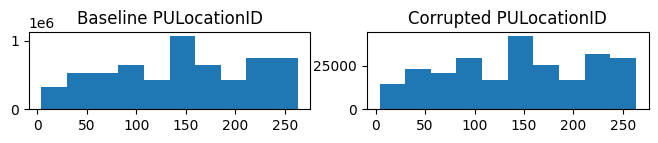

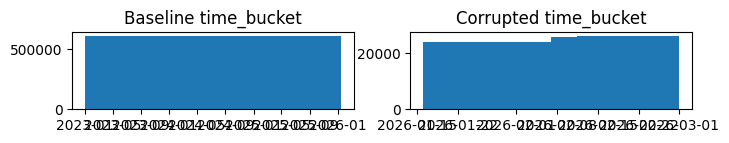

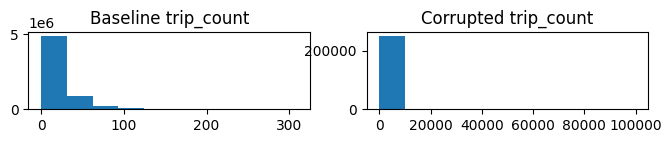

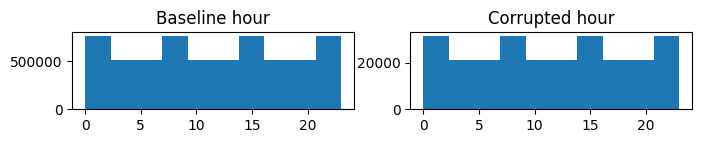

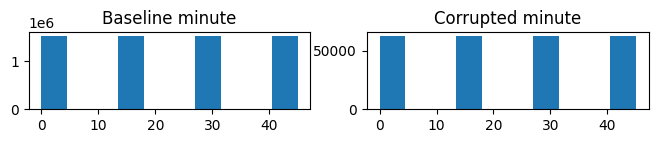

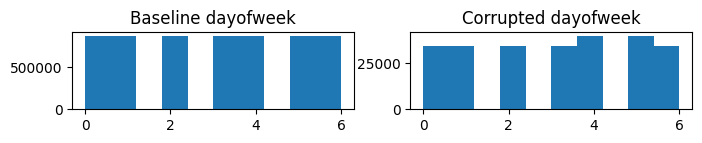

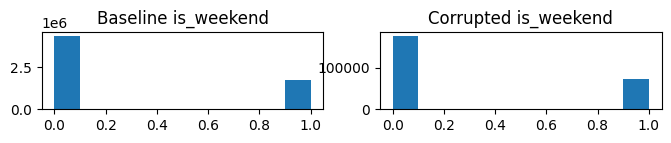

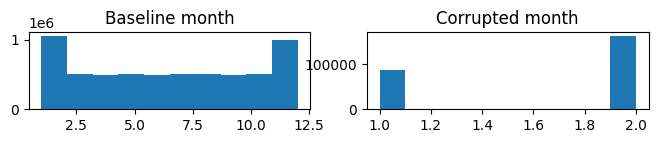

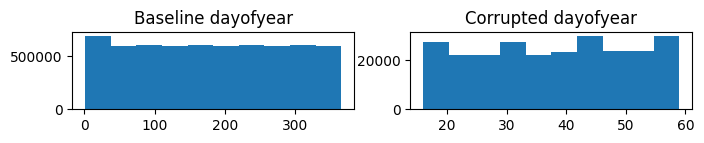

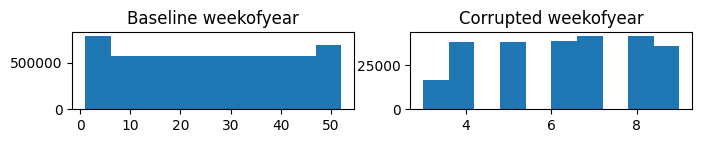

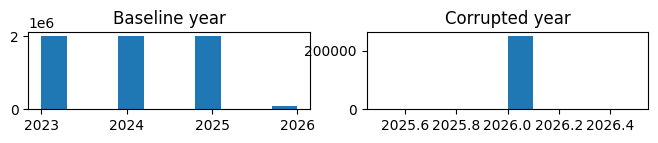

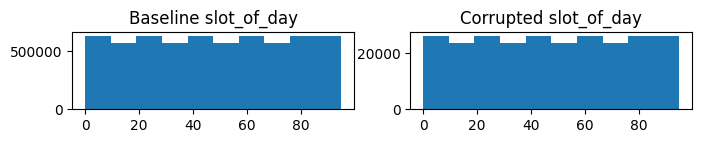

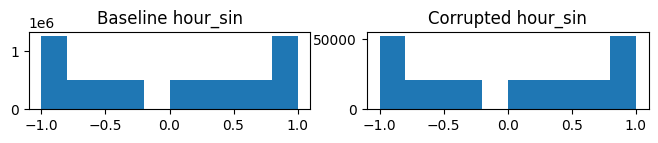

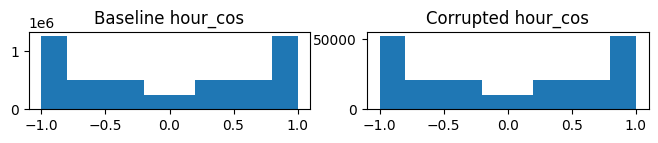

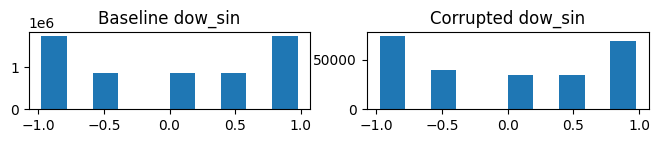

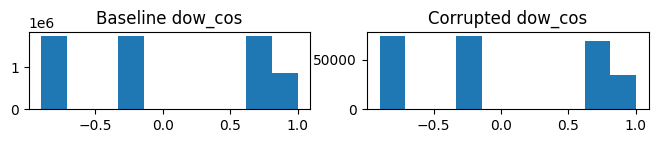

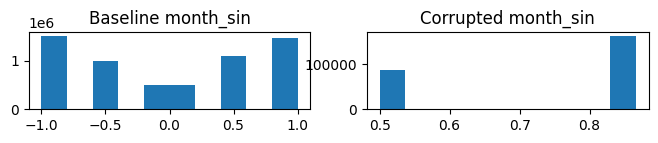

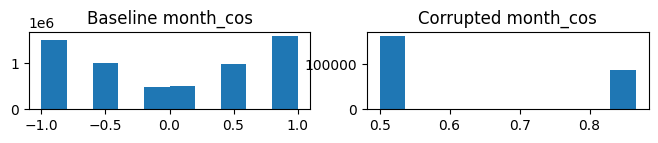

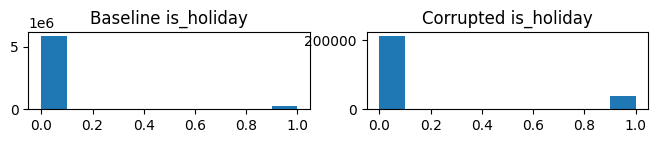

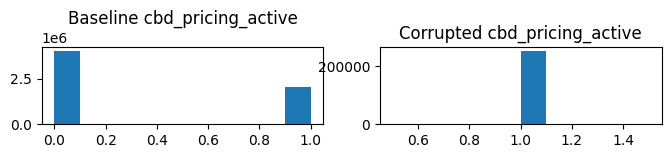

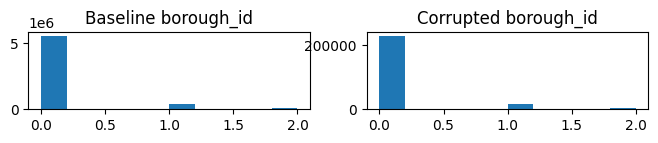

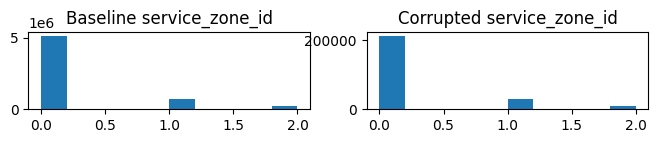

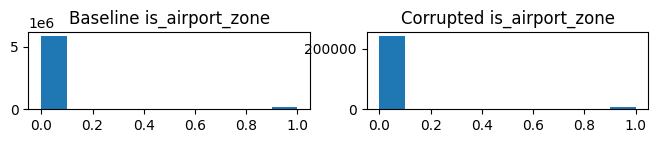

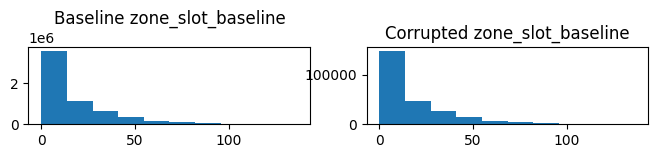

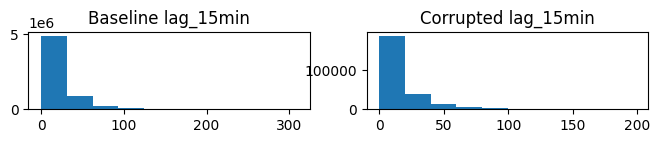

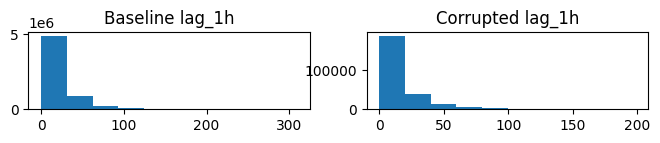

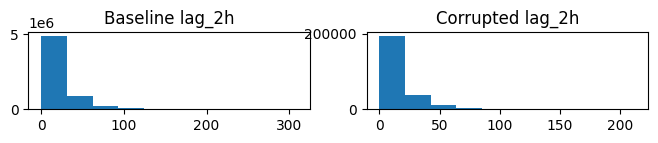

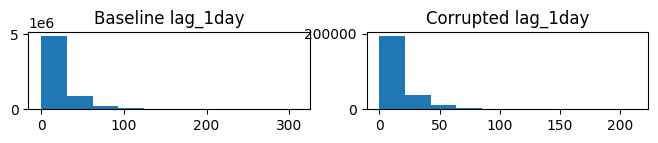

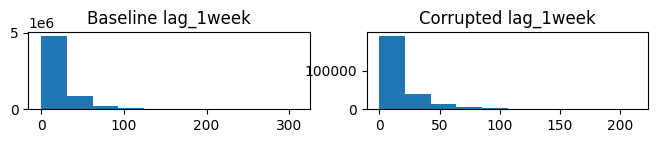

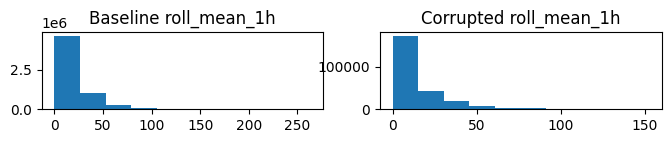

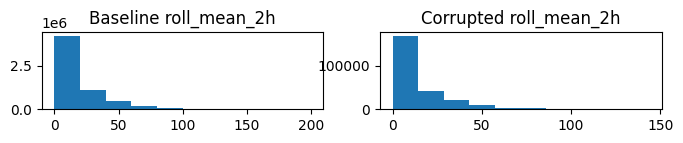

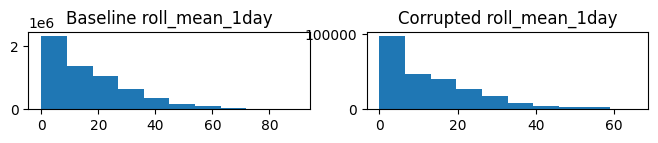

In [23]:
for col in baseline.columns:
  fig, axes = plt.subplots(1, 2, figsize=(8, 1))
  axes[0].hist(baseline[col])
  axes[1].hist(corrupted[col])
  axes[0].set_title(f"Baseline {col}")
  axes[1].set_title(f"Corrupted {col}")
  plt.show()


In [24]:
baseline.isna().value_counts()

PULocationID  time_bucket  trip_count  hour   minute  dayofweek  is_weekend  month  dayofyear  weekofyear  year   slot_of_day  hour_sin  hour_cos  dow_sin  dow_cos  month_sin  month_cos  is_holiday  cbd_pricing_active  borough_id  service_zone_id  is_airport_zone  zone_slot_baseline  lag_15min  lag_1h  lag_2h  lag_1day  lag_1week  roll_mean_1h  roll_mean_2h  roll_mean_1day
False         False        False       False  False   False      False       False  False      False       False  False        False     False     False    False    False      False      False       False               False       False            False            False               False      False   False   False     False      False         False         False             6041088
                                                                                                                                                                                                                                             

In [25]:
corrupted.isna().value_counts()

PULocationID  time_bucket  trip_count  hour   minute  dayofweek  is_weekend  month  dayofyear  weekofyear  year   slot_of_day  hour_sin  hour_cos  dow_sin  dow_cos  month_sin  month_cos  is_holiday  cbd_pricing_active  borough_id  service_zone_id  is_airport_zone  zone_slot_baseline  lag_15min  lag_1h  lag_2h  lag_1day  lag_1week  roll_mean_1h  roll_mean_2h  roll_mean_1day
False         False        False       False  False   False      False       False  False      False       False  False        False     False     False    False    False      False      False       False               False       False            False            False               False      False   False   False     False      False         False         False             250853
Name: count, dtype: int64

In [26]:
# check the ratio of the statustics of the baseline and corrupted dfs to find outliers and major deviations
b_details = baseline.describe()
c_details = corrupted.describe()

for col in baseline.columns:
  print(col)
  details = pd.concat([b_details[col], c_details[col]], axis=1)
  for idx, (v1, v2) in details.iterrows():
    try:
      print(f"{idx}: \t{(abs(v1 - v2)/(v1+0.000001)):.2}")
    except TypeError as e:
      print(e)

PULocationID
count: 	0.96
mean: 	0.014
min: 	0.0
25%: 	0.011
50%: 	0.007
75%: 	0.0
max: 	0.0
std: 	0.012
time_bucket
count: 	0.96
unsupported operand type(s) for +: 'Timestamp' and 'float'
unsupported operand type(s) for +: 'Timestamp' and 'float'
unsupported operand type(s) for +: 'Timestamp' and 'float'
unsupported operand type(s) for +: 'Timestamp' and 'float'
unsupported operand type(s) for +: 'Timestamp' and 'float'
unsupported operand type(s) for +: 'Timestamp' and 'float'
std: 	nan
trip_count
count: 	0.96
mean: 	3.6
min: 	5e+06
25%: 	0.5
50%: 	0.33
75%: 	0.24
max: 	3.2e+02
std: 	1.1e+02
hour
count: 	0.96
mean: 	2e-05
min: 	0.0
25%: 	0.043
50%: 	0.043
75%: 	0.043
max: 	0.0
std: 	1.9e-05
minute
count: 	0.96
mean: 	2e-05
min: 	0.0
25%: 	0.33
50%: 	0.33
75%: 	0.33
max: 	0.0
std: 	9.9e-06
dayofweek
count: 	0.96
mean: 	0.023
min: 	0.0
25%: 	0.0
50%: 	0.0
75%: 	0.0
max: 	0.0
std: 	0.0091
is_weekend
count: 	0.96
mean: 	0.034
min: 	0.0
25%: 	0.0
50%: 	0.0
75%: 	0.0
max: 	0.0
std: 	0.01
m

In [27]:
corrupted.describe()

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
count,250853.000000,250853,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,...,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000,250853.000000
mean,143.539005,2026-02-07 10:57:57.438580224,78.672804,11.500229,22.500448,3.065481,0.295077,1.650983,37.962113,6.270948,...,0.033677,16.741651,13.583325,13.576493,13.574520,13.621842,14.889257,13.579822,13.577316,13.621077
min,4.000000,2026-01-16 00:00:00,-5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,16.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,87.000000,2026-01-27 11:00:00,1.000000,6.000000,15.000000,1.000000,0.000000,1.000000,27.000000,5.000000,...,0.000000,2.169697,1.000000,1.000000,1.000000,1.000000,1.000000,1.250000,1.375000,3.375000
50%,142.000000,2026-02-07 22:00:00,6.000000,12.000000,30.000000,3.000000,0.000000,2.000000,38.000000,6.000000,...,0.000000,8.884848,6.000000,6.000000,6.000000,6.000000,7.000000,6.000000,6.000000,10.614583
75%,211.000000,2026-02-18 11:00:00,19.000000,18.000000,45.000000,5.000000,1.000000,2.000000,49.000000,8.000000,...,0.000000,25.084848,19.000000,19.000000,19.000000,19.000000,21.000000,19.500000,19.500000,20.239584
max,263.000000,2026-02-28 23:45:00,99999.000000,23.000000,45.000000,6.000000,1.000000,2.000000,59.000000,9.000000,...,1.000000,136.763636,199.000000,199.000000,213.000000,213.000000,213.000000,152.250000,143.500000,65.541664
std,72.804804,NaN,2433.026184,6.922322,16.770677,1.982495,0.456078,0.476660,12.702045,1.841399,...,0.180397,19.793022,18.627035,18.619234,18.622976,18.755178,20.041496,18.112823,17.837410,12.514426


Review of the above ...
- null values
- data types
  - validate what's being reported
  attempt to recover or cull
- numeric values
  - we are running a tree model, i don't think independence or linearity are conerns
  - negatives values present in trip_count
  look at thedistrubtion of valuues
    - corrupted tripcount histogram has absurdly large range, must be some erroneous high values
    - perhaps gaps in weekofyear for the corrupted set, even though it should have continuous data
    - what are month_sin, month_cos value

In [77]:
corrupted.describe()['hour']['min']

0.0

In [28]:
for i in zip(baseline.dtypes, corrupted.dtypes):
  print(i[0]==i[1], i)

True (dtype('int64'), dtype('int64'))
True (dtype('<M8[ns]'), dtype('<M8[ns]'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int8'), dtype('int8'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('int64'), dtype('int64'))
True (dtype('int32'), dtype('int32'))
True (dtype('int32'), dtype('int32'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('float64'), dtype('float64'))
True (dtype('int8'), dtype('int8'))
True (dtype('int8'), dtype('int8'))
True (dtype('int64'), dtype('int64'))
True (dtype('int64'), dtype('int64'))
True (dtype('int8'), dtype('int8'))
True (dtype('float64'), dtype('float64'))
True (dtype('float32'), dtype('float32'))
True (dtype('float32')

In [29]:
corrupted[corrupted.trip_count < 0]

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
107155,4,2026-01-21 04:45:00,-1,4,45,2,0,1,21,4,...,0,0.048485,0.0,0.0,0.0,0.0,2.0,0.00,0.125,0.479167
107772,4,2026-01-27 15:00:00,-1,15,0,1,0,1,27,5,...,0,0.351515,0.0,0.0,0.0,0.0,118.0,0.25,0.250,0.239583
108067,4,2026-01-30 16:45:00,-1,16,45,4,0,1,30,5,...,0,0.496970,1.0,1.0,0.0,0.0,103.0,0.50,0.375,0.927083
110216,4,2026-02-22 02:00:00,-5,2,0,6,1,2,53,8,...,0,12.151515,28.0,18.0,13.0,18.0,10.0,23.50,20.750,3.697917
110329,4,2026-02-23 06:15:00,-5,6,15,0,0,2,54,9,...,0,0.084848,0.0,0.0,0.0,0.0,4.0,0.00,0.000,0.208333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6326569,107,2026-02-11 17:15:00,-1,17,15,2,0,2,42,7,...,0,30.115152,25.0,21.0,32.0,23.0,27.0,24.50,25.625,17.687500
6326619,107,2026-02-12 05:45:00,-1,5,45,3,0,2,43,7,...,0,3.806061,4.0,0.0,0.0,3.0,4.0,2.00,1.000,18.364584
6327219,107,2026-02-18 11:45:00,-1,11,45,2,0,2,49,8,...,0,24.733333,18.0,20.0,21.0,22.0,19.0,16.00,17.875,14.520833
6327946,107,2026-02-26 01:30:00,-1,1,30,3,0,2,57,9,...,0,4.248485,2.0,4.0,4.0,2.0,2.0,3.50,5.125,14.614583


In [30]:
corrupted[corrupted.trip_count > baseline.trip_count.max()]

,PULocationID,time_bucket,trip_count,hour,minute,dayofweek,is_weekend,month,dayofyear,weekofyear,...,is_airport_zone,zone_slot_baseline,lag_15min,lag_1h,lag_2h,lag_1day,lag_1week,roll_mean_1h,roll_mean_2h,roll_mean_1day
107451,4,2026-01-24 06:45:00,9999,6,45,5,1,1,24,4,...,0,0.109091,0.0,0.0,0.0,0.0,6.0,0.00,0.000,3.218750
107853,4,2026-01-28 11:15:00,9999,11,15,2,0,1,28,5,...,0,0.430303,0.0,0.0,0.0,0.0,78.0,0.00,0.250,0.354167
108054,4,2026-01-30 13:30:00,9999,13,30,4,0,1,30,5,...,0,0.466667,1.0,0.0,0.0,0.0,141.0,0.25,0.125,0.906250
110610,4,2026-02-26 04:30:00,99999,4,30,3,0,2,57,9,...,0,0.048485,0.0,1.0,0.0,0.0,0.0,0.25,0.125,0.583333
110615,4,2026-02-26 05:45:00,9999,5,45,3,0,2,57,9,...,0,0.030303,0.0,0.0,0.0,0.0,3.0,0.00,0.000,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323554,43,2026-02-22 08:00:00,99999,8,0,6,1,2,53,8,...,0,3.800000,4.0,3.0,1.0,3.0,2.0,2.75,2.250,13.062500
6324135,43,2026-02-28 09:15:00,9999,9,15,5,1,2,59,9,...,0,10.169697,9.0,6.0,3.0,14.0,11.0,8.00,5.250,12.989583
6326255,107,2026-02-08 10:45:00,9999,10,45,6,1,2,39,6,...,0,21.036364,11.0,9.0,8.0,14.0,27.0,12.50,12.000,18.260416
6328248,229,2026-02-08 04:45:00,99999,4,45,6,1,2,39,6,...,0,1.939394,0.0,0.0,5.0,1.0,1.0,0.50,2.125,13.833333


Validation based on above: 
- column presence -> critical if not, abort 
- additional columns -> warn
- range checks +/- 20% based on baseline (for numerical values) -> drop offending columns and warn
- duplicate IDs present?  -> drop offending rows and warn 

In [38]:
len(baseline.index.unique()) == len(baseline)

True

In [39]:
len(corrupted.index.unique()) == len(corrupted)


True

In [ ]:
len(corrupted) - len(corrupted.index.unique())

0

In [43]:
baseline.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
6315931    False
6315932    False
6315933    False
6315934    False
6315935    False
Length: 6079392, dtype: bool

In [58]:
corrupted.duplicated().value_counts()[1]

/var/folders/t0/vjz2r6l1155639x6cpfr8z3h0000gn/T/ipykernel_25706/356436327.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corrupted.duplicated().value_counts()[1]


8134

In [48]:
dedup = corrupted[~corrupted.duplicated()]

In [49]:
len(corrupted)

250853

In [50]:
len(dedup)

242719

In [51]:
if not corrupted.index.is_unique: 
    corrupted.reset_index()

In [113]:
for col, val in baseline.isna().sum().items(): 
    print(col, val)
    

PULocationID 0
time_bucket 0
trip_count 0
hour 0
minute 0
dayofweek 0
is_weekend 0
month 0
dayofyear 0
weekofyear 0
year 0
slot_of_day 0
hour_sin 0
hour_cos 0
dow_sin 0
dow_cos 0
month_sin 0
month_cos 0
is_holiday 0
cbd_pricing_active 0
borough_id 0
service_zone_id 0
is_airport_zone 0
zone_slot_baseline 0
lag_15min 57
lag_1h 228
lag_2h 456
lag_1day 5472
lag_1week 38304
roll_mean_1h 57
roll_mean_2h 57
roll_mean_1day 57


In [ ]:
for row in corrupted.isna().sum().iterrows(): 
    print(row)

AttributeError: 'Series' object has no attribute 'iterrows'